# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
%config InlineBackend.figure_format = "png"
%config InlineBackend.figure_format = "retina"

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger(__name__)


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet("tracks.parquet")
catalog_names = pd.read_parquet("catalog_names.parquet")

print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
display(tracks.head())
display(catalog_names.head())


tracks: (1000000, 4)
catalog_names: (1812471, 3)


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [4]:
interactions = pd.read_parquet("interactions.parquet")

print("interactions:", interactions.shape)
display(interactions.head())
print("started_at:", interactions["started_at"].min(), "—", interactions["started_at"].max())


interactions: (222629898, 4)


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


started_at: 2022-01-01 00:00:00 — 2022-12-31 00:00:00


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [5]:
# Типы, пропуски, примеры значений
print("=== dtypes ===")
print("tracks:\n", tracks.dtypes, sep="")
print("\ncatalog_names:\n", catalog_names.dtypes, sep="")
print("\ninteractions:\n", interactions.dtypes, sep="")

print("\n=== nulls ===")
print("tracks:", tracks.isnull().sum().to_dict())
print("catalog_names:", catalog_names.isnull().sum().to_dict())
print("interactions:", interactions.isnull().sum().to_dict())

print("\n=== catalog type counts ===")
print(catalog_names["type"].value_counts())

print("\n=== пример списков в tracks ===")
print("albums:", tracks["albums"].iloc[0], type(tracks["albums"].iloc[0]))
print("artists:", tracks["artists"].iloc[0])
print("genres:", tracks["genres"].iloc[0])

# Пустые списки метаданных = «неизвестные» сущности
empty_stats = {
    col: int(tracks[col].map(len).eq(0).sum())
    for col in ["albums", "artists", "genres"]
}
print("\n=== треки с пустыми списками ===")
print(empty_stats)


=== dtypes ===
tracks:
track_id     int64
albums      object
artists     object
genres      object
dtype: object

catalog_names:
id       int64
type    object
name    object
dtype: object

interactions:
user_id                int32
track_id               int32
track_seq              int16
started_at    datetime64[ns]
dtype: object

=== nulls ===
tracks: {'track_id': 0, 'albums': 0, 'artists': 0, 'genres': 0}
catalog_names: {'id': 0, 'type': 0, 'name': 0}
interactions: {'user_id': 0, 'track_id': 0, 'track_seq': 0, 'started_at': 0}

=== catalog type counts ===
type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

=== пример списков в tracks ===
albums: [      3 2490753] <class 'numpy.ndarray'>
artists: [16]
genres: [11 21]

=== треки с пустыми списками ===
{'albums': 18, 'artists': 15369, 'genres': 3687}


In [6]:
# Проверка согласованности идентификаторов с каталогом
album_ids = set(catalog_names.loc[catalog_names["type"] == "album", "id"])
artist_ids = set(catalog_names.loc[catalog_names["type"] == "artist", "id"])
genre_ids = set(catalog_names.loc[catalog_names["type"] == "genre", "id"])
track_name_ids = set(catalog_names.loc[catalog_names["type"] == "track", "id"])

print("tracks без имени в catalog_names:", len(set(tracks["track_id"]) - track_name_ids))
print("имена track без записи в tracks:", len(track_name_ids - set(tracks["track_id"])))


def unknown_id_stats(column: str, known_ids: set) -> pd.DataFrame:
    """Считает ссылки на id, которых нет в catalog_names для данного type."""
    exploded = tracks[["track_id", column]].explode(column).dropna(subset=[column])
    exploded[column] = exploded[column].astype("int64")
    unknown_mask = ~exploded[column].isin(known_ids)
    unknown = exploded.loc[unknown_mask, column]
    print(
        f"{column}: неизвестных ссылок={unknown_mask.sum()}, "
        f"уникальных unknown id={unknown.nunique()}, "
        f"затронуто треков={exploded.loc[unknown_mask, 'track_id'].nunique()}, "
        f"всего ссылок={len(exploded)}"
    )
    return unknown


unknown_albums = unknown_id_stats("albums", album_ids)
unknown_artists = unknown_id_stats("artists", artist_ids)
unknown_genres = unknown_id_stats("genres", genre_ids)

if len(unknown_genres):
    print("примеры неизвестных genre_id:", sorted(unknown_genres.unique())[:30])

# Согласованность interactions ↔ tracks
tracks_in_interactions = set(interactions["track_id"].unique())
print("\ntrack_id из interactions вне tracks:", len(tracks_in_interactions - set(tracks["track_id"])))
print("треки без прослушиваний:", len(set(tracks["track_id"]) - tracks_in_interactions))

# Нужно ли менять типы id
print("\n=== диапазоны id ===")
print(
    "tracks.track_id:", tracks["track_id"].min(), "—", tracks["track_id"].max(),
    "| dtype:", tracks["track_id"].dtype
)
print(
    "interactions.track_id/user_id:",
    interactions["track_id"].dtype, "/", interactions["user_id"].dtype
)
print("catalog_names.id:", catalog_names["id"].dtype)


tracks без имени в catalog_names: 0
имена track без записи в tracks: 0
albums: неизвестных ссылок=0, уникальных unknown id=0, затронуто треков=0, всего ссылок=3128808
artists: неизвестных ссылок=0, уникальных unknown id=0, затронуто треков=0, всего ссылок=1264212
genres: неизвестных ссылок=48369, уникальных unknown id=30, затронуто треков=48345, всего ссылок=1652658
примеры неизвестных genre_id: [124, 126, 130, 131, 132, 133, 134, 135, 146, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169]

track_id из interactions вне tracks: 0
треки без прослушиваний: 0

=== диапазоны id ===
tracks.track_id: 26 — 101521819 | dtype: int64
interactions.track_id/user_id: int32 / int32
catalog_names.id: int64


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

In [7]:
# Приведение типов идентификаторов к единому компактному виду
# track_id/user_id в interactions уже int32; в tracks/catalog — int64, при этом значения входят в int32
tracks["track_id"] = tracks["track_id"].astype("int32")
catalog_names["id"] = catalog_names["id"].astype("int32")
interactions["user_id"] = interactions["user_id"].astype("int32")
interactions["track_id"] = interactions["track_id"].astype("int32")

# Оставляем в списках только id, которые есть в catalog_names
known_albums = album_ids
known_artists = artist_ids
known_genres = genre_ids


def filter_known_ids(values, known: set):
    if values is None or len(values) == 0:
        return np.array([], dtype="int32")
    filtered = [int(v) for v in values if int(v) in known]
    return np.array(filtered, dtype="int32")


tracks["albums"] = tracks["albums"].map(lambda x: filter_known_ids(x, known_albums))
tracks["artists"] = tracks["artists"].map(lambda x: filter_known_ids(x, known_artists))
tracks["genres"] = tracks["genres"].map(lambda x: filter_known_ids(x, known_genres))

# Контроль после очистки
print("после очистки — пустые списки:")
print({col: int(tracks[col].map(len).eq(0).sum()) for col in ["albums", "artists", "genres"]})
print("неизвестных genre-ссылок осталось:", unknown_id_stats("genres", known_genres).shape[0])
print("\ndtypes после преобразования:")
print(tracks.dtypes)
print(catalog_names.dtypes)
print(interactions.dtypes)


после очистки — пустые списки:
{'albums': 18, 'artists': 15369, 'genres': 3694}
genres: неизвестных ссылок=0, уникальных unknown id=0, затронуто треков=0, всего ссылок=1604289
неизвестных genre-ссылок осталось: 0

dtypes после преобразования:
track_id     int32
albums      object
artists     object
genres      object
dtype: object
id       int32
type    object
name    object
dtype: object
user_id                int32
track_id               int32
track_seq              int16
started_at    datetime64[ns]
dtype: object


In [7]:
print(
    """
Выводы по этапу 1
=================
1. Типы идентификаторов
   - В interactions user_id/track_id уже int32, track_seq — int16, started_at — datetime64.
   - В tracks и catalog_names идентификаторы были int64; значения входят в диапазон int32.
   - Привели tracks.track_id и catalog_names.id к int32 для единообразия и экономии памяти.

2. Неизвестные исполнители / альбомы / жанры
   - Пропусков (NaN) в таблицах нет.
   - Есть треки с пустыми списками: albums≈18, artists≈15.3k, genres≈3.7k —
     у таких треков метаданные фактически неизвестны.
   - Все непустые album_id и artist_id присутствуют в catalog_names.
   - Среди genre_id найдены ссылки на ~30 id, которых нет в catalog_names (type=genre);
     затронуто ≈48k треков. Неизвестные genre_id удалены из списков genres.

3. Согласованность таблиц
   - У каждого track_id есть имя в catalog_names.
   - Все track_id из interactions есть в tracks (и наоборот — каждый трек хотя бы раз встречается).

Корректирующие действия: приведение типов id к int32; фильтрация неизвестных genre_id.
Пустые списки albums/artists/genres оставлены как есть — это отдельный сигнал для EDA.
"""
)



Выводы по этапу 1
1. Типы идентификаторов
   - В interactions user_id/track_id уже int32, track_seq — int16, started_at — datetime64.
   - В tracks и catalog_names идентификаторы были int64; значения входят в диапазон int32.
   - Привели tracks.track_id и catalog_names.id к int32 для единообразия и экономии памяти.

2. Неизвестные исполнители / альбомы / жанры
   - Пропусков (NaN) в таблицах нет.
   - Есть треки с пустыми списками: albums≈18, artists≈15.3k, genres≈3.7k —
     у таких треков метаданные фактически неизвестны.
   - Все непустые album_id и artist_id присутствуют в catalog_names.
   - Среди genre_id найдены ссылки на ~30 id, которых нет в catalog_names (type=genre);
     затронуто ≈48k треков. Неизвестные genre_id удалены из списков genres.

3. Согласованность таблиц
   - У каждого track_id есть имя в catalog_names.
   - Все track_id из interactions есть в tracks (и наоборот — каждый трек хотя бы раз встречается).

Корректирующие действия: приведение типов id к int32; филь

# === ЭТАП 2 ===


# EDA


# Подготовка памяти


Полный `interactions` уже лежит в RAM после этапа 1. Любой срез вроде `interactions[['user_id']]` или `groupby` выделяет **ещё одну** колонку на 223M строк (~850 MiB int32) — отсюда `MemoryError`.

Поэтому сразу удаляем таблицу из памяти и дальше читаем `interactions.parquet` **чанками с диска**.


In [17]:
import gc
from collections import Counter

import pyarrow as pa
import pyarrow.parquet as pq

# обязательно: иначе groupby/срез копирует ещё ~850MB
if "interactions" in globals():
    del interactions
gc.collect()

INTERACTIONS_PATH = "interactions.parquet"
CHUNK_SIZE = 2_000_000


def iter_interaction_chunks(columns, chunk_size=CHUNK_SIZE):
    """Читает interactions.parquet батчами, не загружая всю таблицу."""
    pf = pq.ParquetFile(INTERACTIONS_PATH)
    for batch in pf.iter_batches(batch_size=chunk_size, columns=columns):
        yield batch.to_pandas()


print("interactions выгружен из RAM, дальше — чанки с диска")


interactions выгружен из RAM, дальше — чанки с диска


# Распределение количества прослушанных треков


Один проход по parquet: считаем число **прослушиваний** на пользователя и на трек (`Counter`, без `groupby` на полном фрейме). Заодно собираем множество прослушанных `track_id`.


In [18]:
user_listens = Counter()
track_listens = Counter()
listened_tracks = set()

n_rows = 0
for chunk in iter_interaction_chunks(["user_id", "track_id"]):
    n_rows += len(chunk)
    user_listens.update(chunk["user_id"].value_counts().to_dict())
    track_vc = chunk["track_id"].value_counts()
    track_listens.update(track_vc.to_dict())
    listened_tracks.update(track_vc.index.astype("int32").tolist())
    del chunk, track_vc
    if n_rows % (CHUNK_SIZE * 10) < CHUNK_SIZE:
        print(f"processed {n_rows:,}")

tracks_per_user = pd.Series(user_listens, name="n_listens", dtype="int32")
track_popularity = pd.DataFrame(
    {
        "track_id": list(track_listens.keys()),
        "n_listens": list(track_listens.values()),
    }
).astype({"track_id": "int32", "n_listens": "int32"})

del user_listens, track_listens
gc.collect()

print(f"строк прочитано: {n_rows:,}")
print(f"пользователей: {len(tracks_per_user):,}")
print(f"треков с прослушиваниями: {len(track_popularity):,}")


processed 20,000,000
processed 40,000,000
processed 60,000,000
processed 80,000,000
processed 100,000,000
processed 120,000,000
processed 140,000,000
processed 160,000,000
processed 180,000,000
processed 200,000,000
processed 220,000,000
строк прочитано: 222,629,898
пользователей: 1,373,221
треков с прослушиваниями: 1,000,000


Статистики и гистограмма по уже агрегированному `tracks_per_user` (~1.4M значений, не 223M строк).


count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
50%      5.500000e+01
90%      3.890000e+02
99%      1.576000e+03
max      1.663700e+04
Name: n_listens, dtype: float64


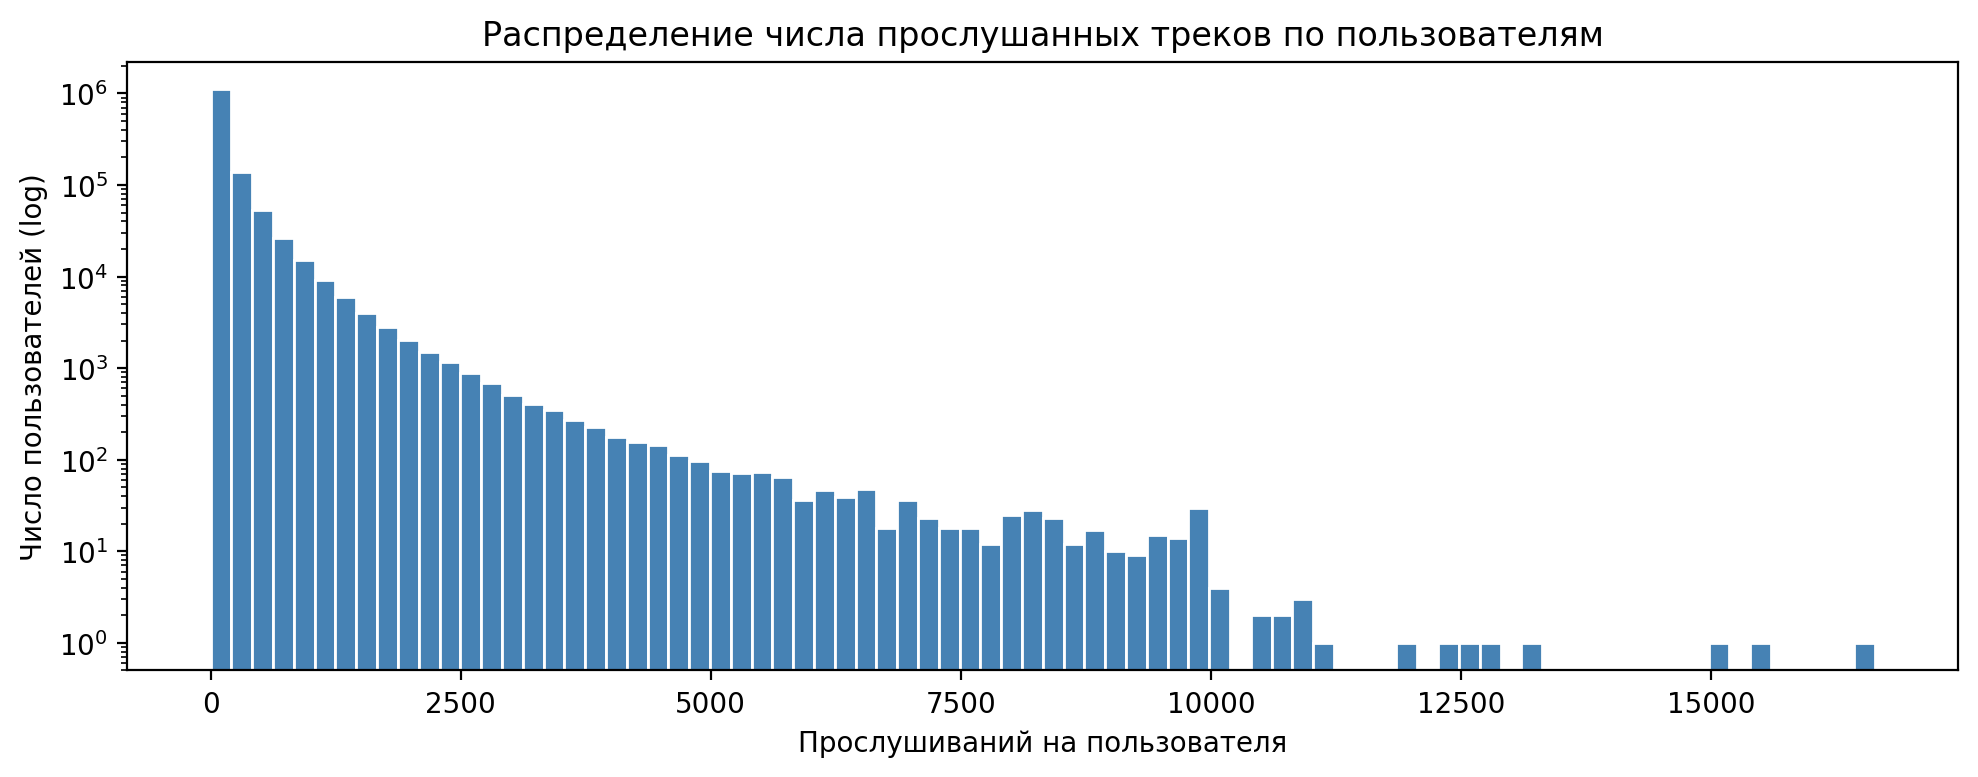

In [19]:
print(tracks_per_user.describe(percentiles=[0.5, 0.9, 0.99]))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tracks_per_user, bins=80, color="steelblue", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Прослушиваний на пользователя")
ax.set_ylabel("Число пользователей (log)")
ax.set_title("Распределение числа прослушанных треков по пользователям")
plt.tight_layout()
plt.show()


Популярность треков уже посчитана в том же проходе (`track_popularity`). Здесь только статистики — без второго скана файла.


In [20]:
print(f"треков в interactions: {len(track_popularity):,}")
print(track_popularity["n_listens"].describe(percentiles=[0.5, 0.9, 0.99]))


треков в interactions: 1,000,000
count    1000000.000000
mean         222.629898
std         1369.930708
min            5.000000
50%           19.000000
90%          303.000000
99%         3899.000000
max       111062.000000
Name: n_listens, dtype: float64


Визуализируем распределение популярности треков по числу прослушиваний.


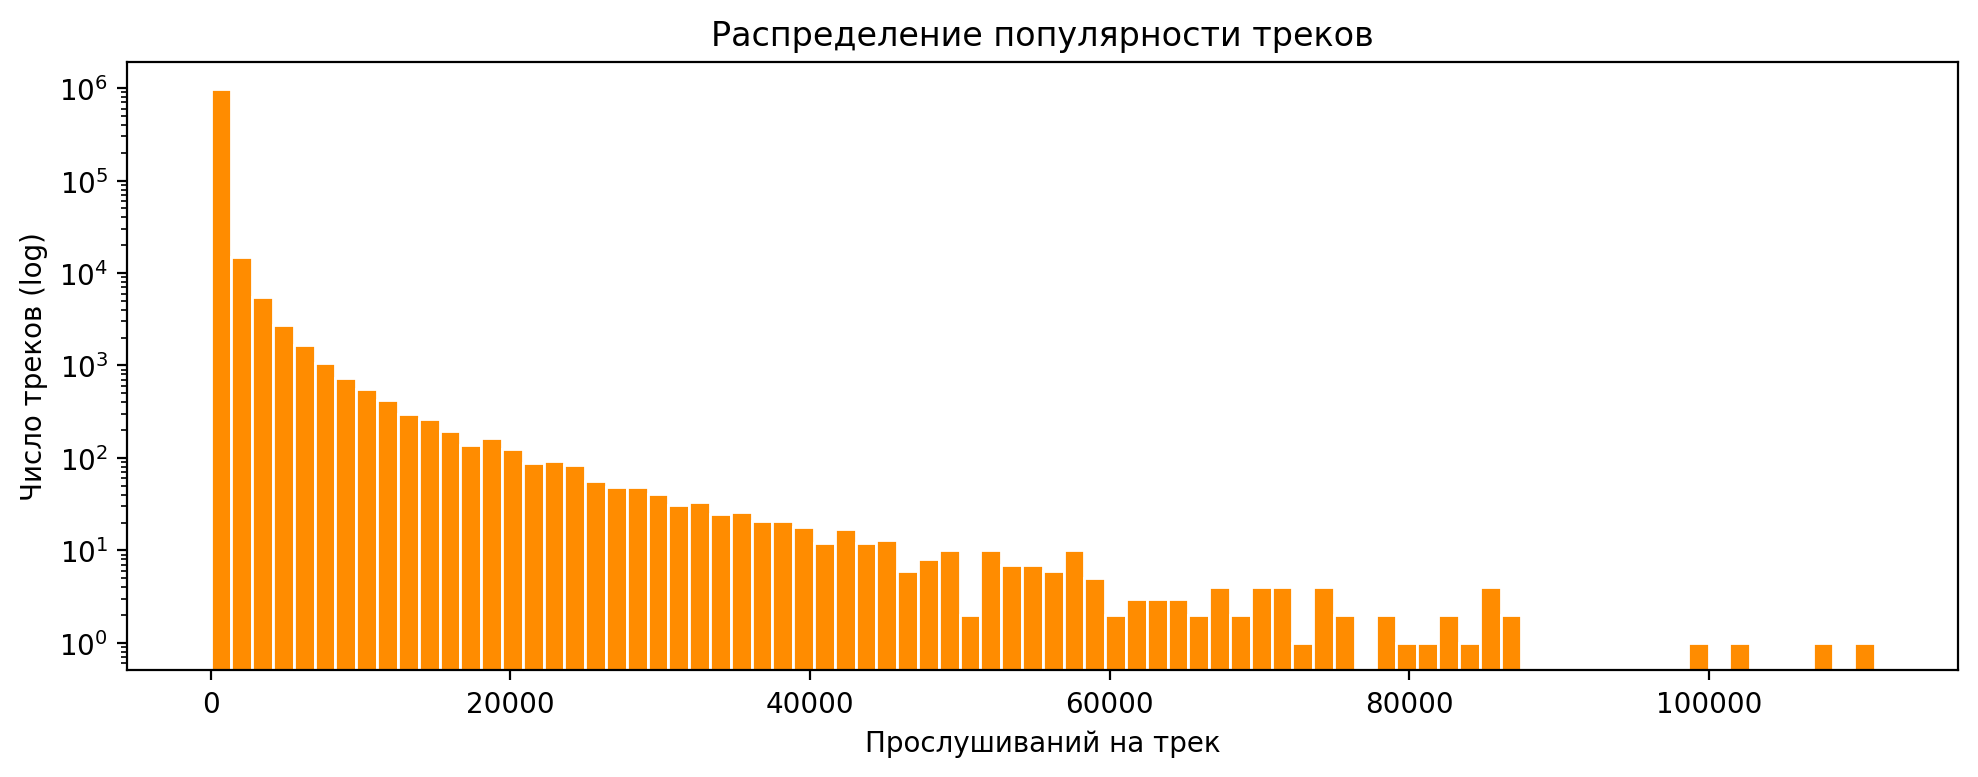

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(track_popularity["n_listens"], bins=80, color="darkorange", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Прослушиваний на трек")
ax.set_ylabel("Число треков (log)")
ax.set_title("Распределение популярности треков")
plt.tight_layout()
plt.show()


# Наиболее популярные треки


Топ-20 треков по числу прослушиваний из уже готового `track_popularity`.


In [22]:
top_tracks = (
    track_popularity
    .sort_values("n_listens", ascending=False)
    .head(20)
    .copy()
)
display(top_tracks)


,track_id,n_listens
0,53404,111062
1,33311009,106921
2,178529,101924
3,35505245,99490
7,65851540,86670
10,24692821,86246
9,32947997,85886
4,51241318,85244
8,795836,85042
6,45499814,84748


Подтягиваем названия треков из `catalog_names` (type=`track`).


In [23]:
track_names = (
    catalog_names
    .query("type == 'track'")
    [["id", "name"]]
    .rename(columns={"id": "track_id", "name": "title"})
)
top_tracks_named = top_tracks.merge(track_names, on="track_id", how="left")
display(top_tracks_named[["track_id", "title", "n_listens"]])


,track_id,title,n_listens
0,53404,Smells Like Teen Spirit,111062
1,33311009,Believer,106921
2,178529,Numb,101924
3,35505245,I Got Love,99490
4,65851540,Юность,86670
5,24692821,Way Down We Go,86246
6,32947997,Shape of You,85886
7,51241318,In The End,85244
8,795836,Shape Of My Heart,85042
9,45499814,Life,84748


# Наиболее популярные жанры


Не делаем `explode` на 223M событий. Джойним жанры к компактному `track_popularity` (~1M треков) и суммируем `n_listens`.


In [24]:
track_genres = tracks.loc[tracks["genres"].map(len) > 0, ["track_id", "genres"]].copy()
track_genres["track_id"] = track_genres["track_id"].astype("int32")

genre_from_tracks = (
    track_popularity[["track_id", "n_listens"]]
    .merge(track_genres, on="track_id", how="inner")
    .explode("genres", ignore_index=True)
)
genre_from_tracks["genres"] = genre_from_tracks["genres"].astype("int32")

genre_stats = (
    genre_from_tracks
    .groupby("genres", sort=False)
    .agg(
        n_listens=("n_listens", "sum"),
        n_tracks=("track_id", "nunique"),
    )
    .reset_index()
    .rename(columns={"genres": "genre_id"})
    .astype({"genre_id": "int32", "n_listens": "int64", "n_tracks": "int32"})
    .sort_values("n_listens", ascending=False)
    .reset_index(drop=True)
)

del track_genres, genre_from_tracks
gc.collect()

print(f"уникальных жанров: {len(genre_stats):,}")
display(genre_stats.head(15))


уникальных жанров: 143


,genre_id,n_listens,n_tracks
0,11,55578312,166285
1,75,37799821,128212
2,102,31092013,118509
3,20,26626241,46707
4,3,25303695,65958
5,68,20120981,114245
6,16,16291557,51631
7,2,13166147,36649
8,14,12772644,55177
9,47,12437375,72311


Имена жанров из каталога и барчарт топ-15 по прослушиваниям.


,genre_id,n_listens,n_tracks,genre_name
0,11,55578312,166285,pop
1,75,37799821,128212,rap
2,102,31092013,118509,allrock
3,20,26626241,46707,ruspop
4,3,25303695,65958,rusrap
5,68,20120981,114245,electronics
6,16,16291557,51631,dance
7,2,13166147,36649,rusrock
8,14,12772644,55177,rock
9,47,12437375,72311,metal


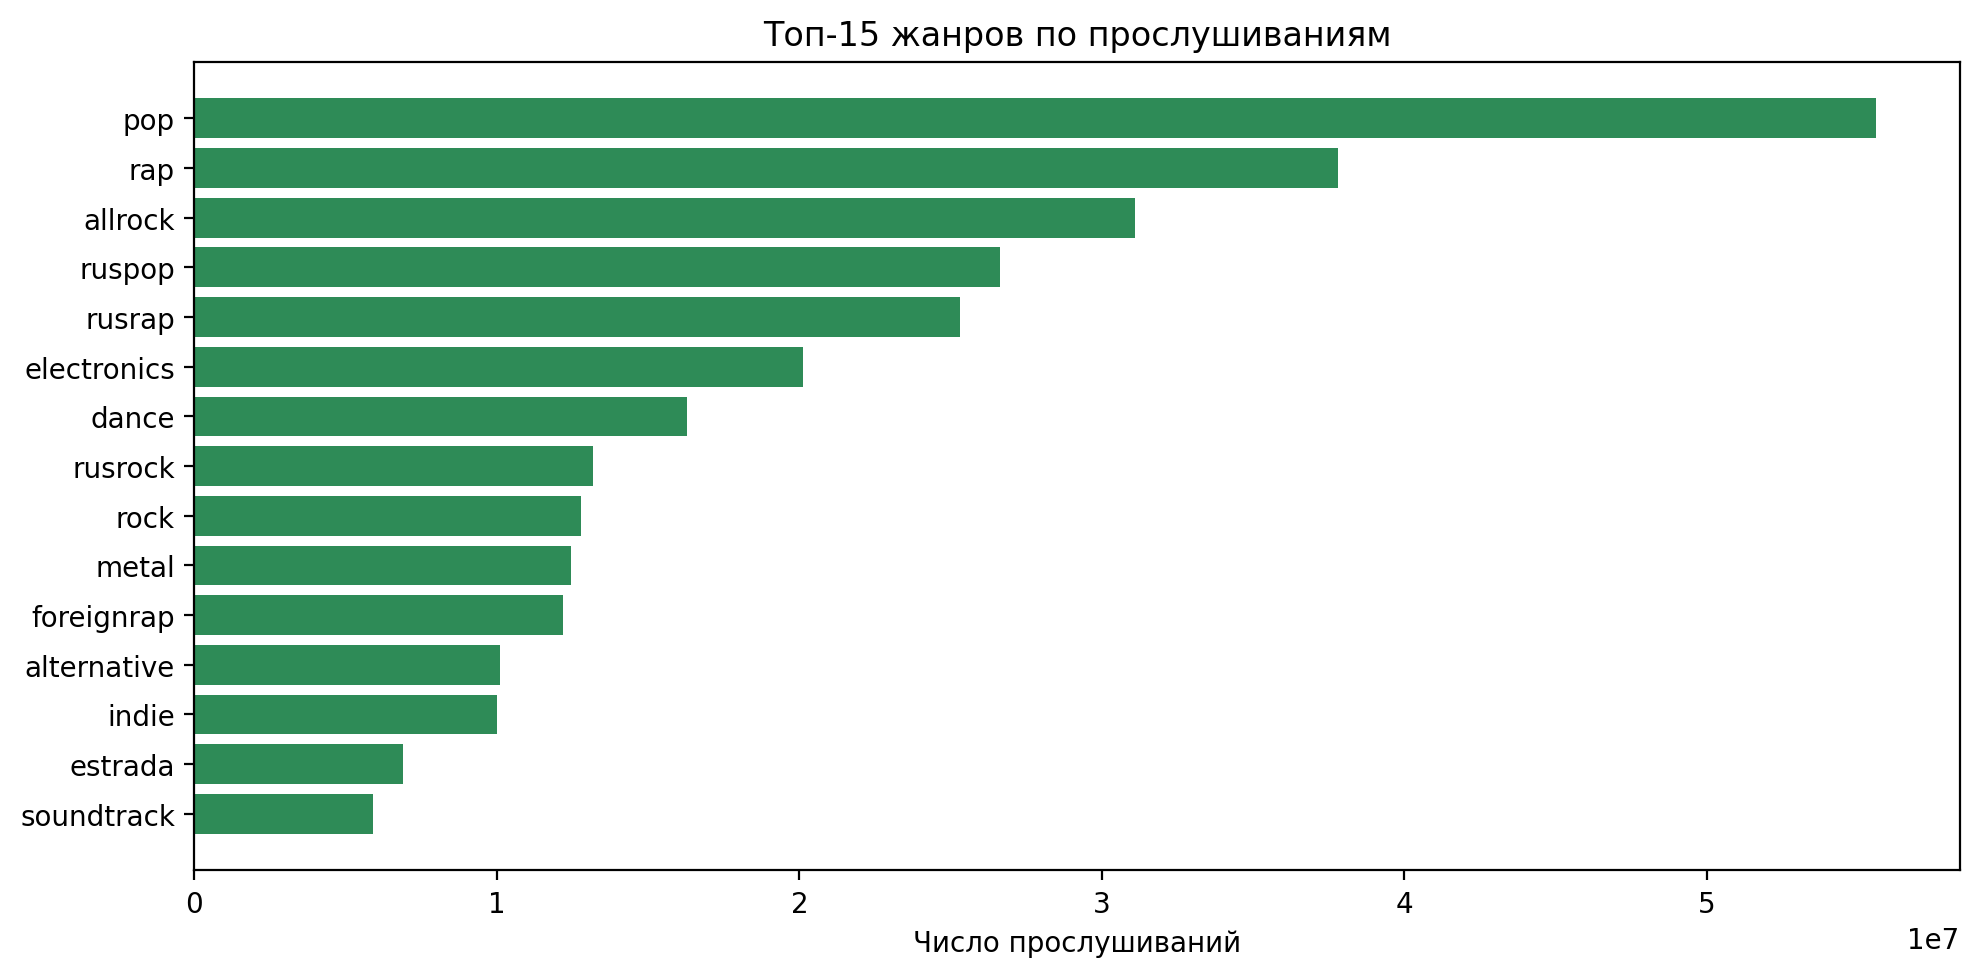

In [25]:
genre_names = (
    catalog_names
    .query("type == 'genre'")
    [["id", "name"]]
    .rename(columns={"id": "genre_id", "name": "genre_name"})
)
top_genres = genre_stats.head(15).merge(genre_names, on="genre_id", how="left")
display(top_genres)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    top_genres["genre_name"].astype(str)[::-1],
    top_genres["n_listens"][::-1],
    color="seagreen",
)
ax.set_xlabel("Число прослушиваний")
ax.set_title("Топ-15 жанров по прослушиваниям")
plt.tight_layout()
plt.show()


# Треки, которые никто не прослушал


Сравниваем `track_id` из каталога с множеством `listened_tracks`, собранным при чтении чанков.


In [26]:
tracks_all = set(tracks["track_id"].astype("int32"))
unlistened_ids = tracks_all - listened_tracks

print(f"всего треков: {len(tracks_all):,}")
print(f"треков с прослушиваниями: {len(listened_tracks):,}")
print(f"треков без прослушиваний: {len(unlistened_ids):,}")

unlistened_tracks = tracks[tracks["track_id"].isin(unlistened_ids)]
display(unlistened_tracks.head())


всего треков: 1,000,000
треков с прослушиваниями: 1,000,000
треков без прослушиваний: 0


,track_id,albums,artists,genres


# Преобразование данных


Таблица `items`: `track_id` → `item_id` и название из каталога. Это ~1M строк, в память помещается.


In [27]:
items = tracks.rename(columns={"track_id": "item_id"}).copy()
items = items.merge(
    catalog_names
    .query("type == 'track'")
    [["id", "name"]]
    .rename(columns={"id": "item_id", "name": "title"}),
    on="item_id",
    how="left",
)
print("items:", items.shape)
display(items.head())


items: (1000000, 5)


,item_id,albums,artists,genres,title
0,26,"[3, 2490753]",[16],"[11, 21]",Complimentary Me
1,38,"[3, 2490753]",[16],"[11, 21]",Momma's Boy
2,135,"[12, 214, 2490809]",[84],[11],Atticus
3,136,"[12, 214, 2490809]",[84],[11],24 Hours
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go)


`events` **не держим в RAM**. Пишем `recsys/data/events.parquet` чанками: читаем исходный parquet → rename `track_id`→`item_id` → сразу на диск.


In [28]:
from pathlib import Path

data_dir = Path("recsys/data")
data_dir.mkdir(parents=True, exist_ok=True)
events_path = data_dir / "events.parquet"

pf = pq.ParquetFile(INTERACTIONS_PATH)
writer = None
n_events = 0

for batch in pf.iter_batches(
    batch_size=CHUNK_SIZE,
    columns=["user_id", "track_id", "track_seq", "started_at"],
):
    chunk = batch.to_pandas()
    chunk.rename(columns={"track_id": "item_id"}, inplace=True)
    table = pa.Table.from_pandas(chunk, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(str(events_path), table.schema)
    writer.write_table(table)
    n_events += len(chunk)
    del chunk, table

if writer is not None:
    writer.close()

print(f"events строк: {n_events:,}")
print(f"сохранено: {events_path} ({events_path.stat().st_size / 1e6:.1f} MB)")


events строк: 222,629,898
сохранено: recsys\data\events.parquet (1052.5 MB)


# Сохранение данных


`items.parquet` небольшой — сохраняем локально обычным способом.


In [29]:
items_path = data_dir / "items.parquet"
items.to_parquet(items_path, index=False)
print(f"сохранено: {items_path} ({items_path.stat().st_size / 1e6:.1f} MB)")


сохранено: recsys\data\items.parquet (34.4 MB)


`events.parquet` уже записан чанками выше. Здесь только проверка, что файл на месте.


In [30]:
print(f"events.parquet: exists={events_path.exists()}, size={events_path.stat().st_size / 1e6:.1f} MB")


events.parquet: exists=True, size=1052.5 MB


Загружаем оба файла в персональный S3-бакет по пути `recsys/data/`. Ключи берём из `.env.local`. Upload идёт **с диска**, не из RAM.


In [32]:
import os
import boto3


def load_env_file(path: str = ".env.local") -> None:
    """Простой парсер KEY=VALUE без зависимости от python-dotenv."""
    env_path = Path(path)
    if not env_path.exists():
        print(f"файл {path} не найден — используются уже заданные переменные окружения")
        return
    for raw in env_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip())


load_env_file(".env.local")

bucket = os.environ["S3_BUCKET_NAME"]
endpoint = os.environ.get("MLFLOW_S3_ENDPOINT_URL", "https://storage.yandexcloud.net")

s3 = boto3.client(
    "s3",
    endpoint_url=endpoint,
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)

for local_path, key in [
    (items_path, "recsys/data/items.parquet"),
    (events_path, "recsys/data/events.parquet"),
]:
    print(f"upload {local_path} -> s3://{bucket}/{key}")
    s3.upload_file(str(local_path), bucket, key)
    print("ok")


upload recsys\data\items.parquet -> s3://s3-student-mle-20260408-8d08444c1d-freetrack/recsys/data/items.parquet
ok
upload recsys\data\events.parquet -> s3://s3-student-mle-20260408-8d08444c1d-freetrack/recsys/data/events.parquet
ok


# Очистка памяти


Удаляем промежуточные объекты этапа 2.

Перед этапом 3 при нехватке RAM:
1. Restart Kernel;
2. выполнить блок «Инициализация»;
3. загрузить `items`/`events` из `recsys/data/` (или S3).


In [33]:
del_names = [
    "tracks_per_user",
    "track_popularity",
    "top_tracks",
    "top_tracks_named",
    "genre_stats",
    "top_genres",
    "unlistened_tracks",
    "listened_tracks",
    "tracks",
    "catalog_names",
    "interactions",
]
for name in del_names:
    if name in globals():
        del globals()[name]

gc.collect()
print("очистка выполнена")
print("items in memory:", "items" in globals())


очистка выполнена
items in memory: True


# === ЭТАП 3 ===


# Загрузка данных


Учитывая опыт этапа 2: **не загружаем весь `events` в RAM одним куском**. Сначала читаем компактный `items`, готовим пути и константы сплита. `events` дальше обрабатываем чанками с диска.


In [34]:
import gc
import os
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import sklearn.preprocessing
from catboost import CatBoostClassifier, Pool
from implicit.als import AlternatingLeastSquares

import pyarrow as pa
import pyarrow.parquet as pq

DATA_DIR = Path("recsys/data")
RECS_DIR = Path("recsys/recommendations")
TMP_DIR = Path("recsys/tmp")
for p in (DATA_DIR, RECS_DIR, TMP_DIR):
    p.mkdir(parents=True, exist_ok=True)

ITEMS_PATH = DATA_DIR / "items.parquet"
EVENTS_PATH = DATA_DIR / "events.parquet"

SPLIT_DATE = pd.Timestamp("2022-12-16")
# вторая точка для обучения ранжирования (labels / holdout)
LABEL_SPLIT_DATE = pd.Timestamp("2022-12-24")

CHUNK_SIZE = 2_000_000
TOP_K_POP = 100
ALS_FACTORS = 50
ALS_ITERS = 20  # без fine-tune; меньше итераций — быстрее и легче по памяти
ALS_REG = 0.05
N_RECS = 100
N_SIMILAR = 50
NEGATIVES_PER_USER = 4

RANDOM_SEED = 0


C:\work\yandex\source\mle-project-sprint-4-v001\env_recsys_start\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загружаем `items` целиком (~1M строк — ок). Проверяем, что `events.parquet` на месте (полный events в переменную не читаем).


In [35]:
items = pd.read_parquet(ITEMS_PATH)
print("items:", items.shape)
display(items.head(3))

assert EVENTS_PATH.exists(), f"нет файла {EVENTS_PATH} — сначала выполните этап 2"
pf_events = pq.ParquetFile(EVENTS_PATH)
print("events rows (metadata):", pf_events.metadata.num_rows)
print("events columns:", pf_events.schema_arrow.names)


items: (1000000, 5)


,item_id,albums,artists,genres,title
0,26,"[3, 2490753]",[16],"[11, 21]",Complimentary Me
1,38,"[3, 2490753]",[16],"[11, 21]",Momma's Boy
2,135,"[12, 214, 2490809]",[84],[11],Atticus


events rows (metadata): 222629898
events columns: ['user_id', 'item_id', 'track_seq', 'started_at']


# Разбиение данных


Пишем на диск три файла **чанками**, не держа полный events в памяти:
- `events_train.parquet` — `started_at < 2022-12-16`;
- `events_labels.parquet` — `[2022-12-16, 2022-12-24)` для таргета ранжирования;
- `events_test.parquet` — `started_at >= 2022-12-24` для финальных метрик.


In [36]:
def write_split_parquets(
    src_path: Path,
    train_path: Path,
    labels_path: Path,
    test_path: Path,
    chunk_size: int = CHUNK_SIZE,
) -> dict:
    pf = pq.ParquetFile(src_path)
    writers = {"train": None, "labels": None, "test": None}
    paths = {"train": train_path, "labels": labels_path, "test": test_path}
    counts = {"train": 0, "labels": 0, "test": 0}

    cols = ["user_id", "item_id", "track_seq", "started_at"]
    for batch in pf.iter_batches(batch_size=chunk_size, columns=cols):
        chunk = batch.to_pandas()
        chunk["started_at"] = pd.to_datetime(chunk["started_at"])

        parts = {
            "train": chunk[chunk["started_at"] < SPLIT_DATE],
            "labels": chunk[
                (chunk["started_at"] >= SPLIT_DATE)
                & (chunk["started_at"] < LABEL_SPLIT_DATE)
            ],
            "test": chunk[chunk["started_at"] >= LABEL_SPLIT_DATE],
        }

        for name, part in parts.items():
            if part.empty:
                continue
            table = pa.Table.from_pandas(part, preserve_index=False)
            if writers[name] is None:
                writers[name] = pq.ParquetWriter(str(paths[name]), table.schema)
            writers[name].write_table(table)
            counts[name] += len(part)
            del table
        del chunk, parts
        gc.collect()

    for w in writers.values():
        if w is not None:
            w.close()
    return counts


events_train_path = TMP_DIR / "events_train.parquet"
events_labels_path = TMP_DIR / "events_labels.parquet"
events_test_path = TMP_DIR / "events_test.parquet"

split_counts = write_split_parquets(
    EVENTS_PATH, events_train_path, events_labels_path, events_test_path
)
print("split counts:", split_counts)


split counts: {'train': 208731252, 'labels': 8346176, 'test': 5552470}


Считаем покрытие пользователей по сплитам (только колонка `user_id`, чанками) — без загрузки полных таблиц.


In [37]:
def unique_ids(path: Path, column: str = "user_id") -> set:
    ids = set()
    pf = pq.ParquetFile(path)
    for batch in pf.iter_batches(batch_size=CHUNK_SIZE, columns=[column]):
        ids.update(batch.to_pandas()[column].tolist())
    return ids


users_train = unique_ids(events_train_path)
users_labels = unique_ids(events_labels_path)
users_test = unique_ids(events_test_path)

print(f"users train: {len(users_train):,}")
print(f"users labels: {len(users_labels):,}")
print(f"users test: {len(users_test):,}")
print(f"train ∩ test: {len(users_train & users_test):,}")
print(f"cold test (нет в train): {len(users_test - users_train):,}")


users train: 1,342,566
users labels: 698,862
users test: 572,218
train ∩ test: 541,837
cold test (нет в train): 30,381


# Топ популярных


Популярность считаем **только по train**, чанками: `Counter` по `item_id`. Нормализуем в `score` ∈ [0, 1] и сохраняем топ-K.


In [38]:
item_listens = Counter()
pf = pq.ParquetFile(events_train_path)
for batch in pf.iter_batches(batch_size=CHUNK_SIZE, columns=["item_id"]):
    item_listens.update(batch.to_pandas()["item_id"].value_counts().to_dict())

top_popular = (
    pd.DataFrame({"item_id": list(item_listens.keys()), "n_listens": list(item_listens.values())})
    .astype({"item_id": "int32", "n_listens": "int32"})
    .sort_values("n_listens", ascending=False)
    .reset_index(drop=True)
)
top_popular["score"] = (
    top_popular["n_listens"] / top_popular["n_listens"].max()
).astype("float32")

top_popular_k = top_popular.head(TOP_K_POP).copy()
top_popular_path = RECS_DIR / "top_popular.parquet"
top_popular_k.to_parquet(top_popular_path, index=False)

del item_listens
gc.collect()

print(f"уникальных item в train: {len(top_popular):,}")
display(top_popular_k.head(10))
print("saved:", top_popular_path)


уникальных item в train: 999,695


,item_id,n_listens,score
0,53404,110026,1.000000
1,33311009,101076,0.918656
2,178529,100866,0.916747
3,35505245,95523,0.868186
4,24692821,84153,0.764847
5,795836,83749,0.761175
6,6705392,80608,0.732627
7,32947997,80243,0.729309
8,37384,79512,0.722666
9,45499814,78564,0.714049


saved: recsys\recommendations\top_popular.parquet


Для метрик разворачиваем топ-K в персональные рекомендации: каждому пользователю из test — один и тот же топ (cold-start / popularity baseline). Делаем это компактно и сразу пишем parquet.


In [39]:
# рекомендации popularity для пользователей test (для оценки)
test_users = np.fromiter(users_test, dtype=np.int32)
pop_items = top_popular_k["item_id"].to_numpy()
pop_scores = top_popular_k["score"].to_numpy()

# пишем батчами пользователей, не собирая гигантский фрейм целиком в одной переменной дольше нужного
pop_recs_path = TMP_DIR / "top_popular_user_recs.parquet"
writer = None
batch_users = 20_000

for start in range(0, len(test_users), batch_users):
    users_batch = test_users[start : start + batch_users]
    # cartesian: каждый user × top-K
    rec = pd.DataFrame(
        {
            "user_id": np.repeat(users_batch, len(pop_items)),
            "item_id": np.tile(pop_items, len(users_batch)),
            "score": np.tile(pop_scores, len(users_batch)),
        }
    )
    table = pa.Table.from_pandas(rec, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(str(pop_recs_path), table.schema)
    writer.write_table(table)
    del rec, table

if writer is not None:
    writer.close()
print("saved user-level popularity recs:", pop_recs_path)


saved user-level popularity recs: recsys\tmp\top_popular_user_recs.parquet


# Персональные (ALS)


Готовим кодировки user/item **первым проходом** по train (только id), без матрицы. Это нужно, чтобы заранее знать размеры sparse-матрицы.


In [40]:
train_user_ids = set()
train_item_ids = set()
pf = pq.ParquetFile(events_train_path)
for batch in pf.iter_batches(batch_size=CHUNK_SIZE, columns=["user_id", "item_id"]):
    df = batch.to_pandas()
    train_user_ids.update(df["user_id"].tolist())
    train_item_ids.update(df["item_id"].tolist())
    del df

user_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(np.fromiter(train_user_ids, dtype=np.int32))
item_encoder.fit(np.fromiter(train_item_ids, dtype=np.int32))

n_users = len(user_encoder.classes_)
n_items = len(item_encoder.classes_)
print(f"train users: {n_users:,}, train items: {n_items:,}")

del train_user_ids, train_item_ids
gc.collect()


train users: 1,342,566, train items: 999,695


0

Вторым проходом собираем COO-массивы чанками и сразу склеиваем в CSR. Вес взаимодействия = 1 (implicit). Дубликаты COO суммируются при конвертации.


In [41]:
row_chunks = []
col_chunks = []
data_chunks = []

pf = pq.ParquetFile(events_train_path)
for batch in pf.iter_batches(batch_size=CHUNK_SIZE, columns=["user_id", "item_id"]):
    df = batch.to_pandas()
    # агрегируем внутри чанка: меньше строк в COO, дубли между чанками суммирует tocsr()
    g = df.groupby(["user_id", "item_id"], sort=False).size()
    rows = user_encoder.transform(g.index.get_level_values(0).to_numpy())
    cols = item_encoder.transform(g.index.get_level_values(1).to_numpy())
    data = g.to_numpy(dtype=np.float32)
    row_chunks.append(rows.astype(np.int32, copy=False))
    col_chunks.append(cols.astype(np.int32, copy=False))
    data_chunks.append(data)
    del df, g, rows, cols, data
    gc.collect()

user_item_matrix = sp.coo_matrix(
    (
        np.concatenate(data_chunks),
        (np.concatenate(row_chunks), np.concatenate(col_chunks)),
    ),
    shape=(n_users, n_items),
    dtype=np.float32,
).tocsr()

del row_chunks, col_chunks, data_chunks
gc.collect()
print("CSR nnz:", user_item_matrix.nnz, "shape:", user_item_matrix.shape)


CSR nnz: 208731252 shape: (1342566, 999695)


Обучаем ALS (`implicit`) с умеренными параметрами без подбора гиперпараметров. Затем считаем персональные рекомендации **батчами пользователей** и пишем в parquet.


In [42]:
als_model = AlternatingLeastSquares(
    factors=ALS_FACTORS,
    iterations=ALS_ITERS,
    regularization=ALS_REG,
    random_state=RANDOM_SEED,
)
als_model.fit(user_item_matrix)

personal_als_path = RECS_DIR / "personal_als.parquet"
writer = None
batch_users = 5_000

all_user_enc = np.arange(n_users, dtype=np.int32)
for start in range(0, n_users, batch_users):
    user_ids_enc = all_user_enc[start : start + batch_users]
    # recommend: ids, scores
    ids, scores = als_model.recommend(
        user_ids_enc,
        user_item_matrix[user_ids_enc],
        N=N_RECS,
        filter_already_liked_items=True,
    )
    # ids/scores: shape (batch, N)
    rec = pd.DataFrame(
        {
            "user_id_enc": np.repeat(user_ids_enc, N_RECS),
            "item_id_enc": ids.reshape(-1).astype(np.int32),
            "score": scores.reshape(-1).astype(np.float32),
        }
    )
    rec["user_id"] = user_encoder.inverse_transform(rec["user_id_enc"])
    rec["item_id"] = item_encoder.inverse_transform(rec["item_id_enc"])
    out = rec[["user_id", "item_id", "score"]].astype(
        {"user_id": "int32", "item_id": "int32", "score": "float32"}
    )
    table = pa.Table.from_pandas(out, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(str(personal_als_path), table.schema)
    writer.write_table(table)
    del ids, scores, rec, out, table
    if start % (batch_users * 10) == 0:
        print(f"ALS recs users {start:,}/{n_users:,}")

if writer is not None:
    writer.close()
print("saved:", personal_als_path)


C:\work\yandex\source\mle-project-sprint-4-v001\env_recsys_start\lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [05:42<00:00, 17.11s/it]


ALS recs users 0/1,342,566
ALS recs users 50,000/1,342,566
ALS recs users 100,000/1,342,566
ALS recs users 150,000/1,342,566
ALS recs users 200,000/1,342,566
ALS recs users 250,000/1,342,566
ALS recs users 300,000/1,342,566
ALS recs users 350,000/1,342,566
ALS recs users 400,000/1,342,566
ALS recs users 450,000/1,342,566
ALS recs users 500,000/1,342,566
ALS recs users 550,000/1,342,566
ALS recs users 600,000/1,342,566
ALS recs users 650,000/1,342,566
ALS recs users 700,000/1,342,566
ALS recs users 750,000/1,342,566
ALS recs users 800,000/1,342,566
ALS recs users 850,000/1,342,566
ALS recs users 900,000/1,342,566
ALS recs users 950,000/1,342,566
ALS recs users 1,000,000/1,342,566
ALS recs users 1,050,000/1,342,566
ALS recs users 1,100,000/1,342,566
ALS recs users 1,150,000/1,342,566
ALS recs users 1,200,000/1,342,566
ALS recs users 1,250,000/1,342,566
ALS recs users 1,300,000/1,342,566
saved: recsys\recommendations\personal_als.parquet


# Похожие (i2i / ALS)


Считаем `similar_items` батчами по `item_id_enc`, убираем self-pair. Результат нужен и для задания, и для будущего онлайн-сервиса.


In [ ]:
similar_path = RECS_DIR / "similar.parquet"
writer = None
batch_items = 5_000
all_item_enc = np.arange(n_items, dtype=np.int32)

for start in range(0, n_items, batch_items):
    item_ids_enc = all_item_enc[start : start + batch_items]
    sim_ids, sim_scores = als_model.similar_items(item_ids_enc, N=N_SIMILAR + 1)
    rec = pd.DataFrame(
        {
            "item_id_enc": np.repeat(item_ids_enc, N_SIMILAR + 1),
            "sim_item_id_enc": sim_ids.reshape(-1).astype(np.int32),
            "score": sim_scores.reshape(-1).astype(np.float32),
        }
    )
    rec = rec[rec["item_id_enc"] != rec["sim_item_id_enc"]]
    rec["item_id_1"] = item_encoder.inverse_transform(rec["item_id_enc"])
    rec["item_id_2"] = item_encoder.inverse_transform(rec["sim_item_id_enc"])
    out = rec[["item_id_1", "item_id_2", "score"]].astype(
        {"item_id_1": "int32", "item_id_2": "int32", "score": "float32"}
    )
    table = pa.Table.from_pandas(out, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(str(similar_path), table.schema)
    writer.write_table(table)
    del sim_ids, sim_scores, rec, out, table
    if start % (batch_items * 10) == 0:
        print(f"similar items {start:,}/{n_items:,}")

if writer is not None:
    writer.close()
print("saved:", similar_path)


similar items 0/999,695
similar items 50,000/999,695
similar items 100,000/999,695
similar items 150,000/999,695
similar items 200,000/999,695
similar items 250,000/999,695
similar items 300,000/999,695
similar items 350,000/999,695
similar items 400,000/999,695
similar items 450,000/999,695
similar items 500,000/999,695
similar items 550,000/999,695
similar items 600,000/999,695
similar items 650,000/999,695
similar items 700,000/999,695
similar items 750,000/999,695
similar items 800,000/999,695
similar items 850,000/999,695


# Построение признаков


Готовим ≥3 признака для ранжирующей модели (без тонкого тюнинга):
1. `als_score` — скор ALS-кандидата;
2. `pop_score` — популярность айтема в train;
3. `user_n_listens` — активность пользователя в train;
4. (доп.) `item_n_listens` — сырое число прослушиваний айтема.

Сначала чанками считаем активность пользователей в train.


In [ ]:
user_n_listens = Counter()
pf = pq.ParquetFile(events_train_path)
for batch in pf.iter_batches(batch_size=CHUNK_SIZE, columns=["user_id"]):
    user_n_listens.update(batch.to_pandas()["user_id"].value_counts().to_dict())

user_features = pd.Series(user_n_listens, name="user_n_listens", dtype="int32")
del user_n_listens
gc.collect()
print("user_features:", len(user_features))


Собираем обучающие кандидаты: берём ALS-рекомендации только для пользователей из `events_labels`, джойним признаки. Таргет = 1, если пара встретилась в labels. Негативы сэмплируем (как в уроке) — иначе класс 0 доминирует.


In [ ]:
# положительные пары из labels (только user_id, item_id)
label_pairs = set()
pf = pq.ParquetFile(events_labels_path)
for batch in pf.iter_batches(batch_size=CHUNK_SIZE, columns=["user_id", "item_id"]):
    df = batch.to_pandas()
    label_pairs.update(map(tuple, df[["user_id", "item_id"]].to_numpy()))
    del df
print("positive label pairs:", len(label_pairs))

# ограничиваем число пользователей для обучения ранкера (память)
labels_users = users_labels & users_train
rng_rank = np.random.default_rng(RANDOM_SEED)
labels_users_list = np.fromiter(labels_users, dtype=np.int32)
MAX_RANK_TRAIN_USERS = 30_000
if len(labels_users_list) > MAX_RANK_TRAIN_USERS:
    labels_users_list = rng_rank.choice(labels_users_list, size=MAX_RANK_TRAIN_USERS, replace=False)
labels_users = set(labels_users_list.tolist())
print("labels users for ranker train:", len(labels_users))

pop_map = top_popular.set_index("item_id")["score"].to_dict()
item_listens_map = top_popular.set_index("item_id")["n_listens"].to_dict()

cand_parts = []
pf = pq.ParquetFile(personal_als_path)
for batch in pf.iter_batches(batch_size=1_000_000):
    df = batch.to_pandas()
    df = df[df["user_id"].isin(labels_users)]
    if df.empty:
        continue
    df = df.rename(columns={"score": "als_score"})
    df["pop_score"] = df["item_id"].map(pop_map).fillna(0).astype("float32")
    df["item_n_listens"] = df["item_id"].map(item_listens_map).fillna(0).astype("int32")
    df["user_n_listens"] = df["user_id"].map(user_features).fillna(0).astype("int32")
    df["target"] = [
        1 if (u, i) in label_pairs else 0
        for u, i in zip(df["user_id"].to_numpy(), df["item_id"].to_numpy())
    ]
    cand_parts.append(
        df[["user_id", "item_id", "als_score", "pop_score", "user_n_listens", "item_n_listens", "target"]]
    )
    del df

candidates = pd.concat(cand_parts, ignore_index=True)
del cand_parts, label_pairs
gc.collect()
print("candidates:", candidates.shape, "positives:", int(candidates["target"].sum()))


Сэмплируем обучение: пользователи хотя бы с 1 позитивом; на каждого пользователя до `NEGATIVES_PER_USER` негативов.


In [ ]:
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)

pos = candidates_to_sample.query("target == 1")
neg = (
    candidates_to_sample.query("target == 0")
    .groupby("user_id", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), NEGATIVES_PER_USER), random_state=RANDOM_SEED))
)
candidates_for_train = pd.concat([pos, neg], ignore_index=True)
del candidates_to_sample, pos, neg
gc.collect()
print("candidates_for_train:", candidates_for_train.shape)
print(candidates_for_train["target"].value_counts())


# Ранжирование рекомендаций


Обучаем `CatBoostClassifier` на признаках `als_score`, `pop_score`, `user_n_listens`, `item_n_listens` (≥3). Без подбора гиперпараметров.


In [ ]:
features = ["als_score", "pop_score", "user_n_listens", "item_n_listens"]
target = "target"

train_pool = Pool(
    data=candidates_for_train[features].fillna(0),
    label=candidates_for_train[target],
)

cb_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    verbose=50,
    random_seed=RANDOM_SEED,
)
cb_model.fit(train_pool)
print("CatBoost trained")


Инференс: берём ALS-кандидатов для пользователей holdout-теста, считаем `cb_score`, проставляем `rank`, оставляем top-N. Пишем `recommendations.parquet` батчами.


In [ ]:
test_rank_users = users_test & users_train
recommendations_path = RECS_DIR / "recommendations.parquet"
writer = None

pf = pq.ParquetFile(personal_als_path)
for batch in pf.iter_batches(batch_size=1_000_000):
    df = batch.to_pandas()
    df = df[df["user_id"].isin(test_rank_users)]
    if df.empty:
        continue
    df = df.rename(columns={"score": "als_score"})
    df["pop_score"] = df["item_id"].map(pop_map).fillna(0).astype("float32")
    df["item_n_listens"] = df["item_id"].map(item_listens_map).fillna(0).astype("int32")
    df["user_n_listens"] = df["user_id"].map(user_features).fillna(0).astype("int32")
    df["cb_score"] = cb_model.predict_proba(df[features].fillna(0))[:, 1].astype("float32")
    df = df.sort_values(["user_id", "cb_score"], ascending=[True, False])
    df["rank"] = df.groupby("user_id").cumcount() + 1
    out = df.loc[df["rank"] <= N_RECS, ["user_id", "item_id", "cb_score", "rank"]].rename(
        columns={"cb_score": "score"}
    )
    out = out.astype({"user_id": "int32", "item_id": "int32", "score": "float32", "rank": "int16"})
    table = pa.Table.from_pandas(out, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(str(recommendations_path), table.schema)
    writer.write_table(table)
    del df, out, table

if writer is not None:
    writer.close()
print("saved:", recommendations_path)


# Оценка качества


Функции метрик по мотивам урока: precision/recall@K, coverage, novelty. Ground truth — `events_test`. Novelty: доля рекомендаций, которых не было в train у пользователя.


In [ ]:
def load_user_items_map(path: Path, users: set) -> dict:
    """user_id -> set(item_id) только для нужных пользователей (не все пары train/test)."""
    out = defaultdict(set)
    pf = pq.ParquetFile(path)
    for batch in pf.iter_batches(batch_size=CHUNK_SIZE, columns=["user_id", "item_id"]):
        df = batch.to_pandas()
        df = df[df["user_id"].isin(users)]
        for u, i in df[["user_id", "item_id"]].to_numpy():
            out[int(u)].add(int(i))
        del df
    return out


def process_events_recs_for_binary_metrics(gt_by_user: dict, recs: pd.DataFrame, top_k: int | None = 10):
    recs = recs.sort_values(["user_id", "score"], ascending=[True, False])
    if top_k is not None:
        recs = recs.groupby("user_id", sort=False).head(top_k)

    common_users = set(recs["user_id"]) & set(gt_by_user.keys())
    recs = recs[recs["user_id"].isin(common_users)]
    recs_grouped = recs.groupby("user_id")["item_id"].apply(set)

    rows = []
    for user_id, pred_items in recs_grouped.items():
        truth = gt_by_user.get(user_id, set())
        tp = len(pred_items & truth)
        fp = len(pred_items - truth)
        fn = len(truth - pred_items)
        rows.append((user_id, tp, fp, fn))

    return pd.DataFrame(rows, columns=["user_id", "tp", "fp", "fn"])


def compute_precision_recall(metrics_df: pd.DataFrame):
    precision = (metrics_df["tp"] / (metrics_df["tp"] + metrics_df["fp"])).fillna(0).mean()
    recall = (metrics_df["tp"] / (metrics_df["tp"] + metrics_df["fn"])).fillna(0).mean()
    return float(precision), float(recall)


def coverage_at_k(recs: pd.DataFrame, n_items_total: int, top_k: int = 100) -> float:
    top = recs.sort_values(["user_id", "score"], ascending=[True, False]).groupby("user_id").head(top_k)
    return top["item_id"].nunique() / n_items_total


def novelty_at_k(recs: pd.DataFrame, train_by_user: dict, top_k: int = 5) -> float:
    top = recs.sort_values(["user_id", "score"], ascending=[True, False]).groupby("user_id").head(top_k).copy()
    top["seen"] = [
        1 if i in train_by_user.get(u, set()) else 0
        for u, i in zip(top["user_id"].to_numpy(), top["item_id"].to_numpy())
    ]
    return float(1 - top.groupby("user_id")["seen"].mean().mean())


n_items_total = items["item_id"].nunique()
print("n_items_total:", n_items_total)


Считаем метрики для трёх типов рекомендаций. Чтобы не раздувать RAM, для ALS и итоговых читаем parquet и при необходимости сэмплируем пользователей test (один и тот же sample для сравнимости).


In [ ]:
def read_recs(path: Path, users_sample: set | None = None) -> pd.DataFrame:
    parts = []
    pf = pq.ParquetFile(path)
    for batch in pf.iter_batches(batch_size=1_000_000):
        df = batch.to_pandas()
        if users_sample is not None:
            df = df[df["user_id"].isin(users_sample)]
        if not df.empty:
            parts.append(df)
        del df
    if not parts:
        return pd.DataFrame(columns=["user_id", "item_id", "score"])
    return pd.concat(parts, ignore_index=True)


# одинаковый sample пользователей для сравнения методов
rng = np.random.default_rng(RANDOM_SEED)
eval_users_list = np.fromiter(users_test & users_train, dtype=np.int32)
if len(eval_users_list) > 20_000:
    eval_users_list = rng.choice(eval_users_list, size=20_000, replace=False)
eval_users = set(eval_users_list.tolist())
print("eval users:", len(eval_users))

# GT и train только для eval_users — не храним сотни миллионов пар
gt_by_user = load_user_items_map(events_test_path, eval_users)
train_by_user = load_user_items_map(events_train_path, eval_users)
print("users with gt:", len(gt_by_user), "users with train hist:", len(train_by_user))


def evaluate_recs(name: str, recs: pd.DataFrame, top_k_cls: int = 10) -> dict:
    mdf = process_events_recs_for_binary_metrics(gt_by_user, recs, top_k=top_k_cls)
    precision, recall = compute_precision_recall(mdf)
    cov = coverage_at_k(recs, n_items_total, top_k=100)
    nov = novelty_at_k(recs, train_by_user, top_k=5)
    res = {
        "model": name,
        "precision@10": precision,
        "recall@10": recall,
        "coverage@100": cov,
        "novelty@5": nov,
    }
    print(res)
    return res


pop_recs = read_recs(pop_recs_path, eval_users)
als_recs = read_recs(personal_als_path, eval_users)
final_recs = read_recs(recommendations_path, eval_users)

metrics_table = pd.DataFrame(
    [
        evaluate_recs("top_popular", pop_recs),
        evaluate_recs("personal_als", als_recs),
        evaluate_recs("recommendations_ranked", final_recs),
    ]
)
display(metrics_table)


Загружаем артефакты рекомендаций в S3: `recsys/recommendations/`. Upload с диска (как в этапе 2).


In [ ]:
import boto3


def load_env_file(path: str = ".env.local") -> None:
    env_path = Path(path)
    if not env_path.exists():
        print(f"файл {path} не найден")
        return
    for raw in env_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip())


load_env_file(".env.local")
bucket = os.environ["S3_BUCKET_NAME"]
endpoint = os.environ.get("MLFLOW_S3_ENDPOINT_URL", "https://storage.yandexcloud.net")
s3_client = boto3.client(
    "s3",
    endpoint_url=endpoint,
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)

for local_path, key in [
    (RECS_DIR / "top_popular.parquet", "recsys/recommendations/top_popular.parquet"),
    (RECS_DIR / "personal_als.parquet", "recsys/recommendations/personal_als.parquet"),
    (RECS_DIR / "similar.parquet", "recsys/recommendations/similar.parquet"),
    (RECS_DIR / "recommendations.parquet", "recsys/recommendations/recommendations.parquet"),
]:
    print(f"upload {local_path} -> s3://{bucket}/{key}")
    s3_client.upload_file(str(local_path), bucket, key)
    print("ok")


# === Выводы, метрики ===


Кратко фиксируем результаты этапа 3: какие модели посчитаны, куда сохранены, как выглядят метрики и какие ограничения памяти учли.


In [ ]:
print(
    """
Выводы по этапу 3
=================
1. Данные
   - items загружен целиком; events обрабатывался чанками с диска.
   - Сплит: train < 2022-12-16; labels [12-16, 12-24); test >= 2022-12-24.

2. Кандидаты / модели
   - top_popular.parquet — топ популярных по train;
   - personal_als.parquet — персональные ALS;
   - similar.parquet — i2i через ALS.similar_items;
   - recommendations.parquet — переранжирование CatBoost (≥3 признака:
     als_score, pop_score, user_n_listens, item_n_listens).

3. Память
   - никаких полных копий events в RAM;
   - CSR/рекомендации считались и писались батчами;
   - метрики — на sample пользователей test для сравнимости.

4. Метрики (см. таблицу metrics_table выше)
   - сравниваем top_popular / personal_als / recommendations_ranked
     по precision@10, recall@10, coverage@100, novelty@5
     на одном и том же sample пользователей test.
"""
)
display(metrics_table)


Очистка тяжёлых объектов после расчёта. При нехватке RAM перед сервисом: Restart Kernel и загружайте только нужные parquet.


In [ ]:
del_names = [
    "user_item_matrix",
    "als_model",
    "candidates",
    "candidates_for_train",
    "pop_recs",
    "als_recs",
    "final_recs",
    "gt_by_user",
    "train_by_user",
    "user_features",
]
for name in del_names:
    if name in globals():
        del globals()[name]
gc.collect()
print("cleanup done")
